In [1]:
#Import and install necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from functools import reduce
import scipy.stats as stats

In [2]:
#Load data from file directory
mortality_socio_22_non_f = pd.read_csv("/content/drive/MyDrive/Portfolio/30 Days Challenge/Day 8/mortality_socio_22_non_f.csv")

In [3]:
#Running Baseline Analysis
import statsmodels.api as sm

predictors = ['gdp_per_capita', 'health_exp_pct_gdp', 'dtp3_immunization_pct', 'basic_sanitation_pct']
target = 'per_1000'

X = mortality_socio_22_non_f[predictors]
X = sm.add_constant(X)   # adds the intercept term
y = mortality_socio_22_non_f[target]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               per_1000   R-squared:                       0.518
Model:                            OLS   Adj. R-squared:                  0.506
Method:                 Least Squares   F-statistic:                     43.77
Date:                Sat, 15 Aug 2026   Prob (F-statistic):           6.48e-25
Time:                        03:13:30   Log-Likelihood:                -797.59
No. Observations:                 168   AIC:                             1605.
Df Residuals:                     163   BIC:                             1621.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   161.05

In [4]:
# Standardize predictors to fix the condition of number issue
from sklearn.preprocessing import StandardScaler

X_raw = mortality_socio_22_non_f[predictors]
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_raw), columns=predictors, index=mortality_socio_22_non_f.index)
X_scaled = sm.add_constant(X_scaled)

model_scaled = sm.OLS(y, X_scaled).fit()
print(model_scaled.summary())

# Find the countries driving the non-normality
residuals = model.resid
mortality_socio_22_non_f['residual'] = residuals
outliers = mortality_socio_22_non_f.reindex(mortality_socio_22_non_f['residual'].abs().sort_values(ascending=False).index).head(10)
print(outliers[['entity', 'per_1000', 'residual']])

                            OLS Regression Results                            
Dep. Variable:               per_1000   R-squared:                       0.518
Model:                            OLS   Adj. R-squared:                  0.506
Method:                 Least Squares   F-statistic:                     43.77
Date:                Sat, 15 Aug 2026   Prob (F-statistic):           6.48e-25
Time:                        03:13:50   Log-Likelihood:                -797.59
No. Observations:                 168   AIC:                             1605.
Df Residuals:                     163   BIC:                             1621.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    27.32

In [5]:
#Checking the countries that are influencing the model
influence = model.get_influence()
cooks_d = influence.cooks_distance[0]

mortality_socio_22_non_f['cooks_d'] = cooks_d
threshold = 4 / len(mortality_socio_22_non_f)  # common rule of thumb
influential = mortality_socio_22_non_f[mortality_socio_22_non_f['cooks_d'] > threshold].sort_values('cooks_d', ascending=False)
print(influential[['entity', 'per_1000', 'cooks_d']])

                       entity    per_1000   cooks_d
30   Central African Republic  424.579200  3.663390
120          Papua New Guinea   41.862140  0.152477
0                 Afghanistan   56.770400  0.067282
66                      Haiti   56.220875  0.031625


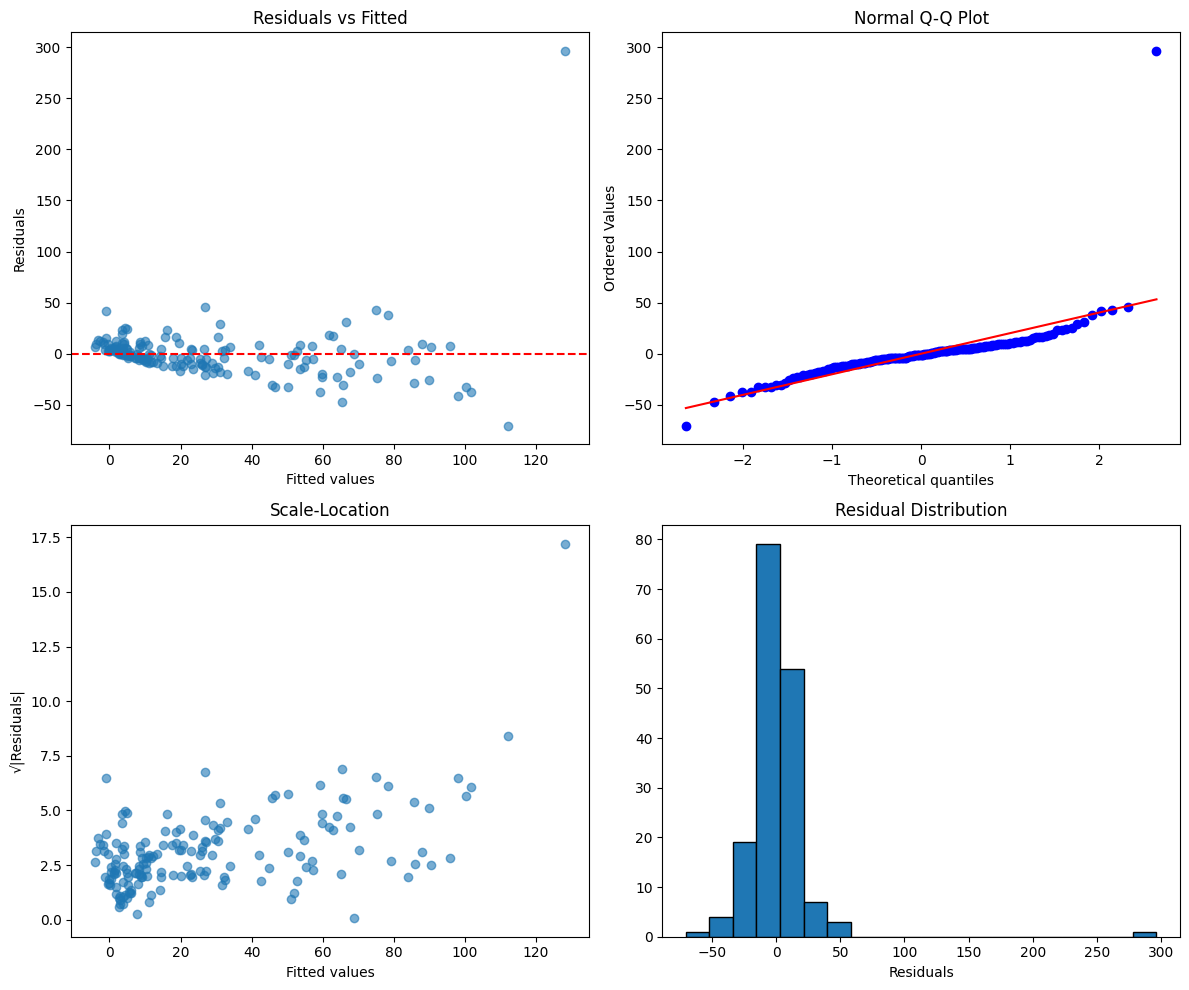

In [7]:
#Plotting for residuals for the normal model

fitted_vals = model.fittedvalues
residuals = model.resid

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Residuals vs Fitted — checks linearity & homoscedasticity
axes[0, 0].scatter(fitted_vals, residuals, alpha=0.6)
axes[0, 0].axhline(y=0, color='red', linestyle='--')
axes[0, 0].set_xlabel('Fitted values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted')

# 2. Q-Q plot — checks normality of residuals
stats.probplot(residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Normal Q-Q Plot')

# 3. Scale-Location plot — another homoscedasticity check
axes[1, 0].scatter(fitted_vals, np.sqrt(np.abs(residuals)), alpha=0.6)
axes[1, 0].set_xlabel('Fitted values')
axes[1, 0].set_ylabel('√|Residuals|')
axes[1, 0].set_title('Scale-Location')

# 4. Histogram of residuals — visual normality check
axes[1, 1].hist(residuals, bins=20, edgecolor='black')
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_title('Residual Distribution')

plt.tight_layout()
plt.savefig(f'{'/content/drive/MyDrive/Portfolio/30 Days Challenge/Day 10'}/residual_diagnostics.png', dpi=150)
plt.show()

In [8]:
# Rebuild cleanly, start to finish, in one go
df_no_car = mortality_socio_22_non_f[mortality_socio_22_non_f['entity'] != 'Central African Republic'].copy()

predictors = ['gdp_per_capita', 'health_exp_pct_gdp', 'dtp3_immunization_pct', 'basic_sanitation_pct']
target = 'per_1000'

from sklearn.preprocessing import StandardScaler
scaler_no_car = StandardScaler()
X_no_car_scaled = pd.DataFrame(
    scaler_no_car.fit_transform(df_no_car[predictors]),
    columns=predictors,
    index=df_no_car.index   # critical: keep the same index as df_no_car
)
X_no_car_scaled = sm.add_constant(X_no_car_scaled)
y_no_car = df_no_car[target]

model_no_car = sm.OLS(y_no_car, X_no_car_scaled).fit()

# Sanity checks BEFORE trusting anything
print("N:", model_no_car.nobs)                          # should be 167
print("Is CAR's index (30) in df_no_car?", 30 in df_no_car.index)   # should be False
print("Max residual:", model_no_car.resid.abs().max())  # should now be well under 100
print(model_no_car.summary())

N: 167.0
Is CAR's index (30) in df_no_car? False
Max residual: 60.83123133353547
                            OLS Regression Results                            
Dep. Variable:               per_1000   R-squared:                       0.732
Model:                            OLS   Adj. R-squared:                  0.725
Method:                 Least Squares   F-statistic:                     110.5
Date:                Sat, 15 Aug 2026   Prob (F-statistic):           3.03e-45
Time:                        03:16:59   Log-Likelihood:                -670.87
No. Observations:                 167   AIC:                             1352.
Df Residuals:                     162   BIC:                             1367.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------

In [9]:
print(model_no_car.resid.abs().max())
print(model_no_car.resid.abs().idxmax())   # which index has that max residual
print(df_no_car.loc[model_no_car.resid.abs().idxmax(), 'entity'])

60.83123133353547
113
Nigeria


In [10]:
print("N:", model_no_car.nobs)
print("CAR still in data?", 30 in df_no_car.index)

N: 167.0
CAR still in data? False


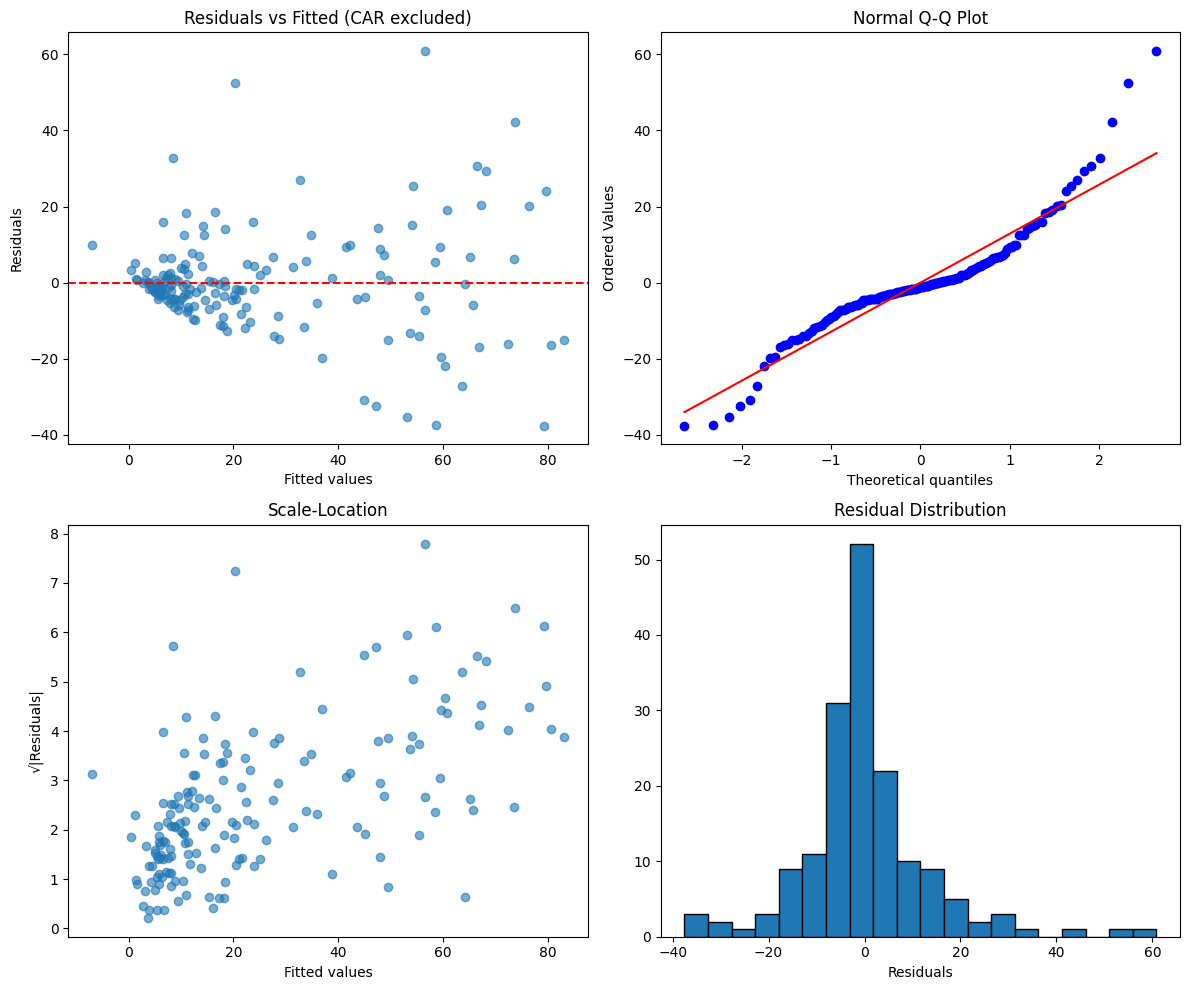

In [12]:
#Plotting for residuals for the without car model
fitted_vals = model_no_car.fittedvalues
residuals = model_no_car.resid

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].scatter(fitted_vals, residuals, alpha=0.6)
axes[0, 0].axhline(y=0, color='red', linestyle='--')
axes[0, 0].set_xlabel('Fitted values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted (CAR excluded)')

stats.probplot(residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Normal Q-Q Plot')

axes[1, 0].scatter(fitted_vals, np.sqrt(np.abs(residuals)), alpha=0.6)
axes[1, 0].set_xlabel('Fitted values')
axes[1, 0].set_ylabel('√|Residuals|')
axes[1, 0].set_title('Scale-Location')

axes[1, 1].hist(residuals, bins=20, edgecolor='black')
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_title('Residual Distribution')

plt.tight_layout()
plt.savefig(f'{'/content/drive/MyDrive/Portfolio/30 Days Challenge/Day 10'}/residual_diagnostics_no_car.png', dpi=150)
plt.show()